In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Mismo estilo The Economist
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.color": "#E5E5E5", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "font.family": "serif",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
})

cfg      = yaml.safe_load(open("../config.yaml"))
TARGET   = cfg["project"]["target_column"]
df_raw   = pd.read_csv(Path("..") / cfg["data"]["raw_path"])

print(f"✓ Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")

✓ Dataset cargado: 307,511 filas × 122 columnas


In [2]:
df = df_raw.copy()

# ── Ratios financieros (desde config.yaml) ────────────────
for ratio in cfg["features"]["ratios"]:
    num   = ratio["numerator"]
    denom = ratio["denominator"]
    name  = ratio["name"]
    df[name] = df[num] / df[denom].replace(0, np.nan)
    print(f"  ✓ {name:30s} = {num} / {denom}")

# ── Features adicionales de economista ───────────────────
df["AGE_YEARS"]           = df["DAYS_BIRTH"].abs() / 365
df["EMPLOYMENT_YEARS"]    = df["DAYS_EMPLOYED"].clip(upper=0).abs() / 365
df["INCOME_PER_PERSON"]   = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"].replace(0, np.nan)
df["CREDIT_TERM_MONTHS"]  = df["AMT_CREDIT"] / df["AMT_ANNUITY"].replace(0, np.nan)

print("\n  ✓ AGE_YEARS")
print("  ✓ EMPLOYMENT_YEARS")
print("  ✓ INCOME_PER_PERSON")
print("  ✓ CREDIT_TERM_MONTHS")
print(f"\n✓ Total features creadas: {df.shape[1] - df_raw.shape[1]}")

  ✓ PAYMENT_RATE                   = AMT_ANNUITY / AMT_INCOME_TOTAL
  ✓ CREDIT_INCOME_RATIO            = AMT_CREDIT / AMT_INCOME_TOTAL
  ✓ CREDIT_GOODS_RATIO             = AMT_CREDIT / AMT_GOODS_PRICE
  ✓ ANNUITY_CREDIT_RATIO           = AMT_ANNUITY / AMT_CREDIT

  ✓ AGE_YEARS
  ✓ EMPLOYMENT_YEARS
  ✓ INCOME_PER_PERSON
  ✓ CREDIT_TERM_MONTHS

✓ Total features creadas: 8


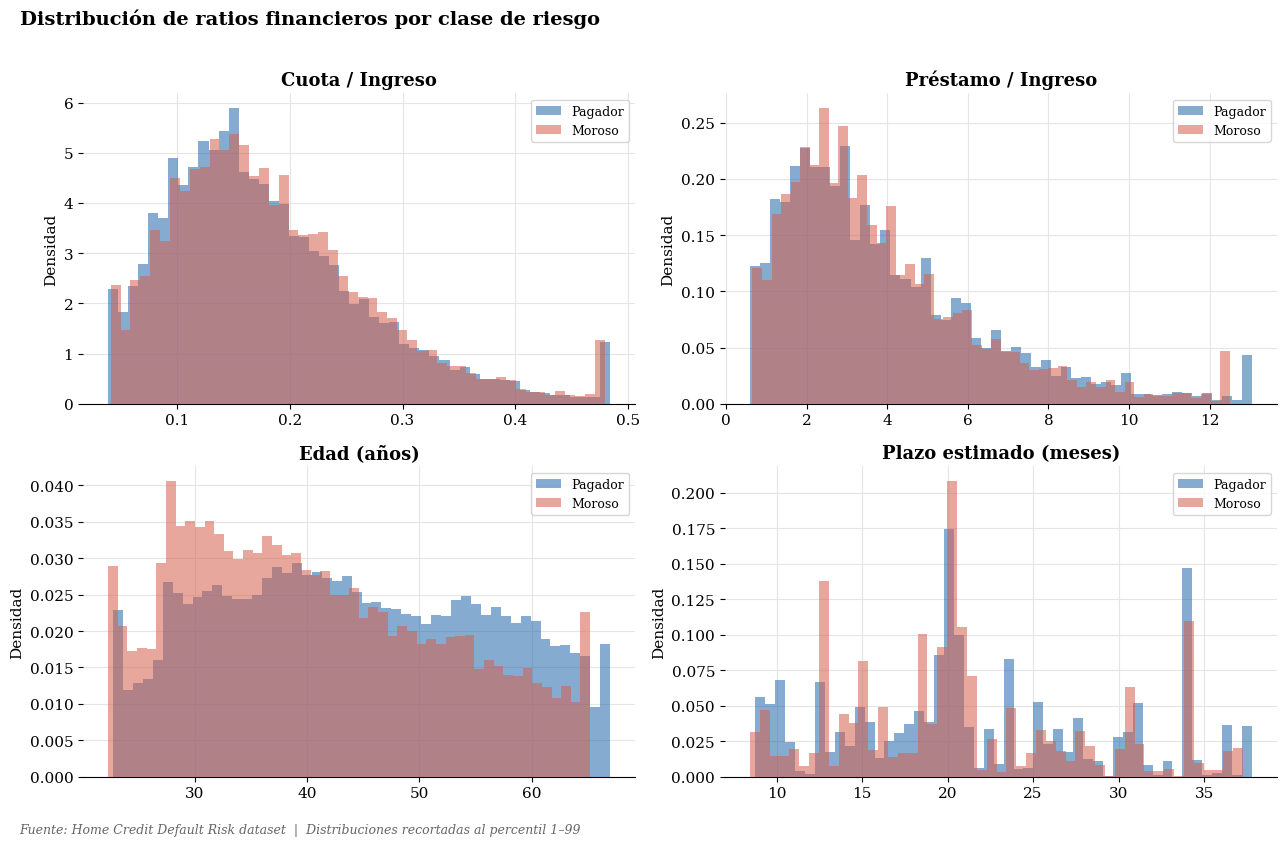

✓ Gráfica guardada


In [3]:
ratios_plot = ["PAYMENT_RATE", "CREDIT_INCOME_RATIO", "AGE_YEARS", "CREDIT_TERM_MONTHS"]
labels_plot = ["Cuota / Ingreso", "Préstamo / Ingreso", "Edad (años)", "Plazo estimado (meses)"]
colores     = ["#2166AC", "#D6604D"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(
    "Distribución de ratios financieros por clase de riesgo",
    fontsize=14, fontweight="bold", x=0.02, ha="left", y=1.01
)

for ax, feat, label in zip(axes.flatten(), ratios_plot, labels_plot):
    for cls, color, nombre in zip([0, 1], colores, ["Pagador", "Moroso"]):
        data = df[df[TARGET] == cls][feat].dropna()
        # Recortar outliers extremos para visualización
        p1, p99 = data.quantile(0.01), data.quantile(0.99)
        data = data.clip(p1, p99)
        ax.hist(data, bins=50, alpha=0.55, color=color,
                label=nombre, density=True, zorder=3)
    ax.set_title(label)
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=9)

fig.text(0.02, -0.02,
    "Fuente: Home Credit Default Risk dataset  |  Distribuciones recortadas al percentil 1–99",
    fontsize=9, color="#666666", style="italic")

plt.tight_layout()
plt.savefig("../model/reports/02_ratios_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Gráfica guardada")

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
import joblib

# ── Separar tipos de columnas ─────────────────────────────
drop_cols = cfg["features"]["drop_columns"] + [TARGET]
X = df.drop(columns=drop_cols, errors="ignore")
y = df[TARGET]

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(f"  Variables numéricas  : {len(num_cols)}")
print(f"  Variables categóricas: {len(cat_cols)}")

# ── Pipeline de preprocesamiento ──────────────────────────
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy=cfg["features"]["imputation"]["numeric_strategy"]))
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy=cfg["features"]["imputation"]["categorical_strategy"])),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

# ── Ajustar y transformar ─────────────────────────────────
X_processed = preprocessor.fit_transform(X)
feature_names = num_cols + cat_cols

print(f"\n✓ Shape después del preprocesamiento: {X_processed.shape}")

  Variables numéricas  : 112
  Variables categóricas: 16

✓ Shape después del preprocesamiento: (307511, 128)


In [5]:
import json

Path("../model/artifacts").mkdir(parents=True, exist_ok=True)
Path("../data/processed").mkdir(parents=True, exist_ok=True)

# Guardar preprocesador
joblib.dump(preprocessor, "../model/artifacts/preprocessor.joblib")

# Guardar nombres de features
with open("../model/artifacts/feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

# Guardar dataset procesado
X_dense = np.array(X_processed)
df_proc = pd.DataFrame(X_dense, columns=feature_names)
df_proc[TARGET] = y.values
df_proc.to_parquet("../data/processed/train_features.parquet", index=False)

print("✓ preprocessor.joblib     → model/artifacts/")
print("✓ feature_names.json      → model/artifacts/")
print("✓ train_features.parquet  → data/processed/")
print(f"\n  Shape final: {df_proc.shape[0]:,} filas × {df_proc.shape[1]} columnas")

✓ preprocessor.joblib     → model/artifacts/
✓ feature_names.json      → model/artifacts/
✓ train_features.parquet  → data/processed/

  Shape final: 307,511 filas × 129 columnas
